# T-JEPA → TabPFNRegressor — GP2 Tabular SSL Research

**Student:** Zain Qerba (160201)  
**Supervisor:** Dana El Rushaidat  
**University:** Jordan University of Science and Technology  

---

## Purpose
This notebook implements **T-JEPA (Tabular Joint-Embedding Predictive Architecture)**
as a self-supervised encoder, then feeds its learned representations into **TabPFNRegressor**
as the downstream model — tested on California Housing at 8 data fractions.



## Pipeline
Raw X_train (no labels) → T-JEPA pretraining → learned embeddings
↓
TabPFNRegressor.fit(embeddings, y_train[fraction])
↓
TabPFNRegressor.predict(X_test_embedded)


## Key Design Decision
T-JEPA pretrains **once** on all unlabeled X_train. The same embeddings are then
used across all 8 fractions — only the labeled subset passed to TabPFN changes.
This is correct SSL behavior: SSL uses all available unlabeled data regardless of
how many labels are available for the downstream task.

## Comparison
| Model | Notes |
|---|---|
| XGBoost (raw features) | Tree baseline |
| TabPFNRegressor (raw features) | Foundation model baseline — notebook 04 |
| **T-JEPA → TabPFNRegressor** | **This notebook ** |

## Dataset
| Dataset | Task | Rows | Features |
|---|---|---|---|
| California Housing | Regression | 20,640 | 8 numerical |

## Metrics
- **RMSE** — Root Mean Squared Error (lower is better)
- **MAE** — Mean Absolute Error (lower is better)
- **R²** — Coefficient of determination (higher is better)

## Citations
Melo, J., et al. (2025). T-JEPA: Augmentation-Free Self-Supervised Learning for Tabular Data.
*ICLR 2025*. https://github.com/jose-melo/t-jepa

Hollmann, N., et al. (2025). TabPFN v2: Improved In-Context Learning for Tabular Data.
*arXiv:2501.02945*.

In [1]:
# ── Cell 1: Install Dependencies ──────────────────────────────────────────────
# tabpfn    — TabPFNv2 foundation model (in-context learning)
# einops    — tensor operations used in transformer blocks
# torch     — T-JEPA implementation
# rest      — standard ML stack

!pip install tabpfn --upgrade einops scikit-learn pandas numpy matplotlib seaborn -q
print("All packages installed successfully.")

All packages installed successfully.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ── Cell 2: TabPFN API Token ───────────────────────────────────────────────────
# Required for TabPFNv2 — register once at ux.priorlabs.ai

import os
os.environ["TABPFN_TOKEN"] = "tabpfn_sk_M_Pjq6pxBD-uUTCYlmAaZr6RGRqp8FZKmMUZ5L0wCuU"

In [3]:
# ── Cell 3: Imports & Config ───────────────────────────────────────────────────
# T-JEPA hyperparameters follow the paper's config for California Housing:
# - batch_size=512, ema_start=0.996, ema_end=1.0, mask_num_preds=4
# - D_MODEL=64, N_HEADS=8, N_LAYERS=3 from the paper's search space
# - All numerical features (CA has 0 categorical features)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import copy
import math
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tabpfn import TabPFNRegressor

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Experiment ────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
FRACTIONS    = [1.0, 0.5, 0.1, 0.08, 0.06, 0.04, 0.02, 0.01]
RESULTS_FILE = '../results/tjepa_tabpfn_results.csv'

# ── T-JEPA Hyperparameters (paper config for California Housing) ───────────────
D_MODEL          = 64      # hidden dimension of context/target encoder
N_HEADS          = 8       # attention heads (D_MODEL must be divisible by N_HEADS)
N_LAYERS         = 3       # transformer layers in context/target encoder
D_FF             = 256     # feedforward dimension in encoder
PRED_D_MODEL     = 32      # hidden dimension of predictor
PRED_N_HEADS     = 4       # attention heads in predictor
PRED_N_LAYERS    = 4       # transformer layers in predictor
DROPOUT          = 0.0     # dropout (paper uses near-zero for CA)
BATCH_SIZE       = 512     # fixed across all datasets in paper
PRETRAIN_EPOCHS  = 200     # paper uses 300, we use 200 for speed
PRETRAIN_PATIENCE= 50      # early stopping patience
WARMUP_EPOCHS    = 10      # linear LR warmup
LR               = 1e-4    # learning rate
EMA_START        = 0.996   # EMA momentum start
EMA_END          = 1.0     # EMA momentum end (linear schedule)
N_PRED_MASKS     = 4       # number of prediction masks per step
N_FEATURES       = 8       # California Housing has 8 features

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
print("Config ready.")

Device: cuda
Config ready.


In [4]:
# ── Cell 4: Load Data & Train/Test Split ───────────────────────────────────────
# StandardScaler fitted on X_train only — no data leakage.
# T-JEPA paper uses z-score normalization for numerical features.

print("Loading California Housing dataset...")
housing  = fetch_california_housing()
X_all    = housing.data.astype(np.float32)
y_all    = housing.target.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
)

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc   = scaler.transform(X_test).astype(np.float32)

print(f"Train : {X_train_sc.shape}")
print(f"Test  : {X_test_sc.shape}")
print(f"Target range: {y_all.min():.2f} — {y_all.max():.2f}")

Loading California Housing dataset...
Train : (16512, 8)
Test  : (4128, 8)
Target range: 0.15 — 5.00


In [5]:
# ── Cell 5: T-JEPA Architecture ────────────────────────────────────────────────
# Three modules following the paper exactly:
#   1. FeatureEmbedder  — per-feature linear projection + positional embeddings
#   2. TransformerBlock — shared for context encoder, target encoder, predictor
#   3. TJEPA            — full model with EMA target encoder and [REG] token

class FeatureEmbedder(nn.Module):
    """Projects each feature independently to d_model dimensions + adds positional embedding."""
    def __init__(self, n_features, d_model):
        super().__init__()
        self.projections    = nn.ModuleList([nn.Linear(1, d_model) for _ in range(n_features)])
        self.pos_embeddings = nn.Embedding(n_features, d_model)
        self.n_features     = n_features

    def forward(self, x, indices):
        embeds = []
        for local_i, global_i in enumerate(indices):
            proj = self.projections[global_i](x[:, local_i:local_i+1])
            pos  = self.pos_embeddings.weight[global_i]
            embeds.append(proj + pos)
        return torch.stack(embeds, dim=1)  # (B, len(indices), d_model)


class TransformerBlock(nn.Module):
    """Standard Transformer encoder with pre-norm."""
    def __init__(self, d_model, n_heads, n_layers, d_ff, dropout=0.0):
        super().__init__()
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)

    def forward(self, x):
        return self.encoder(x)


class TJEPA(nn.Module):
    def __init__(self, n_features, d_model, n_heads, n_layers, d_ff,
                 pred_d_model, pred_n_heads, pred_n_layers, dropout=0.0):
        super().__init__()
        self.n_features = n_features
        self.d_model    = d_model

        self.embedder        = FeatureEmbedder(n_features, d_model)
        self.context_encoder = TransformerBlock(d_model, n_heads, n_layers, d_ff, dropout)

        self.target_encoder  = copy.deepcopy(self.context_encoder)
        for p in self.target_encoder.parameters():
            p.requires_grad = False

        self.reg_token   = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.reg_token, std=0.02)

        self.mask_tokens      = nn.Embedding(n_features, d_model)
        self.pred_input_proj  = nn.Linear(d_model, pred_d_model)
        self.predictor        = TransformerBlock(pred_d_model, pred_n_heads, pred_n_layers,
                                                  pred_d_model * 4, dropout)
        self.pred_output_proj = nn.Linear(pred_d_model, d_model)

    def encode_context(self, x, ctx_idx):
        ctx_x = x[:, ctx_idx]
        h     = self.embedder(ctx_x, ctx_idx)
        reg   = self.reg_token.expand(x.shape[0], -1, -1)
        h_reg = torch.cat([h, reg], dim=1)
        out   = self.context_encoder(h_reg)
        return out[:, :-1, :]

    @torch.no_grad()
    def encode_target(self, x, tgt_idx):
        all_idx = list(range(self.n_features))
        h       = self.embedder(x, all_idx)
        reg     = self.reg_token.expand(x.shape[0], -1, -1)
        h_reg   = torch.cat([h, reg], dim=1)
        out     = self.target_encoder(h_reg)
        return out[:, tgt_idx, :]

    def predict(self, h_ctx, tgt_idx):
        B          = h_ctx.shape[0]
        tgt_tensor = torch.tensor(tgt_idx, device=h_ctx.device)
        mask_tok   = self.mask_tokens(tgt_tensor).unsqueeze(0).expand(B, -1, -1)
        combined   = torch.cat([h_ctx, mask_tok], dim=1)
        projected  = self.pred_input_proj(combined)
        pred_out   = self.predictor(projected)
        tgt_pred   = pred_out[:, h_ctx.shape[1]:, :]
        return self.pred_output_proj(tgt_pred)

    def ema_update(self, momentum):
        for p_c, p_t in zip(self.context_encoder.parameters(),
                             self.target_encoder.parameters()):
            p_t.data = momentum * p_t.data + (1 - momentum) * p_c.data

    @torch.no_grad()
    def extract_embeddings(self, x_tensor):
        # Mean pool over features (dim=1) → (N, d_model=64)
        # Fixed: was mean(dim=-1) → (N, 8), now mean(dim=1) → (N, 64)
        self.eval()
        all_idx = list(range(self.n_features))
        h       = self.embedder(x_tensor, all_idx)
        reg     = self.reg_token.expand(x_tensor.shape[0], -1, -1)
        h_reg   = torch.cat([h, reg], dim=1)
        out     = self.context_encoder(h_reg)
        h_feats = out[:, :-1, :]                   # (N, 8, d_model) drop REG
        return h_feats.mean(dim=1)                 # (N, d_model=64) ← FIXED


# Sanity check
_m   = TJEPA(N_FEATURES, D_MODEL, N_HEADS, N_LAYERS, D_FF,
             PRED_D_MODEL, PRED_N_HEADS, PRED_N_LAYERS, DROPOUT).to(device)
_x   = torch.randn(4, N_FEATURES).to(device)
_emb = _m.extract_embeddings(_x)
print(f"Model params     : {sum(p.numel() for p in _m.parameters()):,}")
print(f"Embedding shape  : {_emb.shape}")   # should be (4, 64)
del _m, _x, _emb
print("T-JEPA architecture ready.")

Model params     : 357,024
Embedding shape  : torch.Size([4, 64])
T-JEPA architecture ready.


In [6]:
# ── Cell 6: Masking & Training Functions ───────────────────────────────────────
# sample_masks: randomly selects context and target feature subsets
# train_tjepa:  full pretraining loop with EMA updates and early stopping

def sample_masks(n_features, n_preds=4):
    """Sample n_preds (context, target) mask pairs per training step."""
    masks = []
    for _ in range(n_preds):
        perm     = np.random.permutation(n_features)
        # Context: 40-75% of features
        ctx_size = np.random.randint(max(1, int(n_features * 0.40)),
                                      max(2, int(n_features * 0.75)) + 1)
        # Target: 1-3 features from the remaining
        remaining = n_features - ctx_size
        tgt_size  = np.random.randint(1, max(2, min(remaining, 3)) + 1)
        ctx_idx = sorted(perm[:ctx_size].tolist())
        tgt_idx = sorted(perm[ctx_size:ctx_size + tgt_size].tolist())
        masks.append((ctx_idx, tgt_idx))
    return masks


def get_ema_momentum(epoch, total_epochs):
    """Linear EMA momentum schedule from EMA_START to EMA_END."""
    return EMA_START + (EMA_END - EMA_START) * epoch / total_epochs


def get_lr(epoch, total_epochs, warmup_epochs, base_lr):
    """Linear warmup then cosine annealing."""
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    return base_lr * 0.5 * (1 + math.cos(math.pi * progress))


def train_tjepa(model, X_np, epochs, patience, batch_size, lr, warmup, device):
    """Pretrain T-JEPA on unlabeled data X_np using masked prediction in latent space."""
    X_tensor = torch.tensor(X_np, dtype=torch.float32)
    loader   = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=1e-4
    )

    best_loss    = float('inf')
    patience_cnt = 0
    best_weights = None

    print(f"  Pretraining T-JEPA on {len(X_np):,} samples for up to {epochs} epochs...")

    for epoch in range(epochs):
        model.train()
        # Update learning rate manually
        new_lr = get_lr(epoch, epochs, warmup, lr)
        for pg in optimizer.param_groups:
            pg['lr'] = new_lr

        epoch_loss = 0.0
        for (x_batch,) in loader:
            x_batch = x_batch.to(device)
            masks   = sample_masks(model.n_features, N_PRED_MASKS)

            total_loss = 0.0
            for ctx_idx, tgt_idx in masks:
                h_ctx    = model.encode_context(x_batch, ctx_idx)   # (B, n_ctx, d_model)
                h_tgt    = model.encode_target(x_batch, tgt_idx)    # (B, n_tgt, d_model)
                h_pred   = model.predict(h_ctx, tgt_idx)            # (B, n_tgt, d_model)
                total_loss += F.mse_loss(h_pred, h_tgt.detach())

            loss = total_loss / N_PRED_MASKS
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            # EMA update after each batch
            momentum = get_ema_momentum(epoch, epochs)
            model.ema_update(momentum)

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)

        if (epoch + 1) % 20 == 0:
            print(f"    Epoch {epoch+1:>3}/{epochs} | Loss: {avg_loss:.4f} | LR: {new_lr:.2e}")

        # Early stopping
        if avg_loss < best_loss - 1e-5:
            best_loss    = avg_loss
            patience_cnt = 0
            best_weights = copy.deepcopy(model.state_dict())
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f"    Early stopping at epoch {epoch+1} (best loss: {best_loss:.4f})")
                break

    if best_weights is not None:
        model.load_state_dict(best_weights)

    print(f"  Pretraining complete. Best loss: {best_loss:.4f}")
    return model


print("Masking and training functions ready.")

Masking and training functions ready.


In [7]:
# ── Cell 7: Pretrain T-JEPA & Extract Embeddings ──────────────────────────────
# T-JEPA trains ONCE on all X_train (no labels).
# Embeddings are mean-pooled over features → (N, 64) — richer than raw (N, 8).
# StandardScaler applied to embeddings before TabPFN — sensitive to scale.

tjepa_model = TJEPA(
    n_features   = N_FEATURES,
    d_model      = D_MODEL,
    n_heads      = N_HEADS,
    n_layers     = N_LAYERS,
    d_ff         = D_FF,
    pred_d_model = PRED_D_MODEL,
    pred_n_heads = PRED_N_HEADS,
    pred_n_layers= PRED_N_LAYERS,
    dropout      = DROPOUT
).to(device)

tjepa_model = train_tjepa(
    model      = tjepa_model,
    X_np       = X_train_sc,
    epochs     = PRETRAIN_EPOCHS,
    patience   = PRETRAIN_PATIENCE,
    batch_size = BATCH_SIZE,
    lr         = LR,
    warmup     = WARMUP_EPOCHS,
    device     = device
)

# Extract embeddings — mean pool over features → (N, 64)
print("\nExtracting embeddings...")
EMBED_BATCH = 1024

def extract_in_batches(model, X_np, batch_size, device):
    model.eval()
    all_embs = []
    for i in range(0, len(X_np), batch_size):
        batch = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32).to(device)
        emb   = model.extract_embeddings(batch).cpu().numpy()
        all_embs.append(emb)
    return np.concatenate(all_embs, axis=0)

X_train_emb_raw = extract_in_batches(tjepa_model, X_train_sc, EMBED_BATCH, device)
X_test_emb_raw  = extract_in_batches(tjepa_model, X_test_sc,  EMBED_BATCH, device)

# Normalize embeddings before passing to TabPFN
from sklearn.preprocessing import StandardScaler as EmbScaler
emb_scaler  = EmbScaler()
X_train_emb = emb_scaler.fit_transform(X_train_emb_raw)
X_test_emb  = emb_scaler.transform(X_test_emb_raw)

print(f"Train embeddings : {X_train_emb.shape}")
print(f"Test  embeddings : {X_test_emb.shape}")
print("Embeddings ready.")

  Pretraining T-JEPA on 16,512 samples for up to 200 epochs...
    Epoch  20/200 | Loss: 0.4917 | LR: 9.94e-05
    Epoch  40/200 | Loss: 0.4637 | LR: 9.44e-05
    Epoch  60/200 | Loss: 0.3441 | LR: 8.45e-05
    Epoch  80/200 | Loss: 0.3917 | LR: 7.08e-05
    Epoch 100/200 | Loss: 0.3317 | LR: 5.50e-05
    Epoch 120/200 | Loss: 0.3594 | LR: 3.85e-05
    Epoch 140/200 | Loss: 0.3725 | LR: 2.33e-05
    Early stopping at epoch 153 (best loss: 0.2908)
  Pretraining complete. Best loss: 0.2908

Extracting embeddings...
Train embeddings : (16512, 64)
Test  embeddings : (4128, 64)
Embeddings ready.


In [8]:
# ── Cell 8: Helper Functions ───────────────────────────────────────────────────

def save_result(row):
    df_new = pd.DataFrame([row])
    if os.path.exists(RESULTS_FILE):
        df_existing = pd.read_csv(RESULTS_FILE)
        df_existing = df_existing[~(
            (df_existing['dataset'] == row['dataset']) &
            (df_existing['fraction'] == row['fraction'])
        )]
        df_new = pd.concat([df_existing, df_new], ignore_index=True)
    df_new.to_csv(RESULTS_FILE, index=False)

def get_completed_fractions():
    if not os.path.exists(RESULTS_FILE):
        return []
    df = pd.read_csv(RESULTS_FILE)
    return df[df['dataset'] == 'california_housing']['fraction'].tolist()

print("Helper functions ready.")

Helper functions ready.


In [9]:
# ── Cell 9: TabPFN on T-JEPA Embeddings — 8 Fractions ─────────────────────────
# For each fraction:
#   1. Subsample labeled training data
#   2. TabPFNRegressor.fit(X_train_emb[fraction], y_train[fraction])
#   3. Evaluate on full test set embeddings
# T-JEPA embeddings are already computed — no retraining needed here.

print("=" * 60)
print("CALIFORNIA HOUSING — T-JEPA → TabPFN across 8 fractions")
print("=" * 60)

completed = get_completed_fractions()

for frac in FRACTIONS:
    if frac in completed:
        print(f"\nFraction: {int(frac*100)}% — already done, skipping")
        continue

    print(f"\nFraction: {int(frac*100)}%")

    # Subsample labeled training data
    if frac == 1.0:
        X_tr_emb = X_train_emb.copy()
        y_tr     = y_train.copy()
    else:
        n_samples = int(len(X_train_emb) * frac)
        _, X_tr_emb, _, y_tr = train_test_split(
            X_train_emb, y_train,
            test_size=n_samples,
            random_state=RANDOM_STATE
        )

    print(f"  Training samples : {len(X_tr_emb):,}")

    # TabPFNRegressor — no hyperparameter tuning needed
    model = TabPFNRegressor(
        device='cuda',
        random_state=RANDOM_STATE,
        ignore_pretraining_limits=True,
        n_estimators=8,
    )
    model.fit(X_tr_emb, y_tr)
    y_pred = model.predict(X_test_emb)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print(f"  TEST → RMSE: {rmse:.4f}  |  MAE: {mae:.4f}  |  R²: {r2:.4f}")

    save_result({
        'dataset'           : 'california_housing',
        'model'             : 'tjepa_tabpfn',
        'fraction'          : frac,
        'n_train_samples'   : len(X_tr_emb),
        'accuracy'          : None, 'macro_f1': None,
        'roc_auc'           : None, 'pr_auc'  : None, 'f1': None,
        'rmse'              : round(rmse, 4),
        'mae'               : round(mae,  4),
        'r2'                : round(r2,   4),
        'best_optuna_params': f'T-JEPA: d_model={D_MODEL},n_heads={N_HEADS},n_layers={N_LAYERS},d_ff={D_FF},pred_d_model={PRED_D_MODEL},lr={LR},epochs={PRETRAIN_EPOCHS} | TabPFN: n_estimators=8,no_tuning'
    })
    print(f"  Saved: dataset=california_housing | fraction={frac}")

print("\nT-JEPA → TabPFN California Housing experiments complete.")

CALIFORNIA HOUSING — T-JEPA → TabPFN across 8 fractions

Fraction: 100%
  Training samples : 16,512
  TEST → RMSE: 0.4499  |  MAE: 0.2836  |  R²: 0.8455
  Saved: dataset=california_housing | fraction=1.0

Fraction: 50%
  Training samples : 8,256
  TEST → RMSE: 0.4733  |  MAE: 0.2990  |  R²: 0.8290
  Saved: dataset=california_housing | fraction=0.5

Fraction: 10%
  Training samples : 1,651
  TEST → RMSE: 0.5425  |  MAE: 0.3554  |  R²: 0.7754
  Saved: dataset=california_housing | fraction=0.1

Fraction: 8%
  Training samples : 1,320
  TEST → RMSE: 0.5613  |  MAE: 0.3698  |  R²: 0.7596
  Saved: dataset=california_housing | fraction=0.08

Fraction: 6%
  Training samples : 990
  TEST → RMSE: 0.5710  |  MAE: 0.3781  |  R²: 0.7512
  Saved: dataset=california_housing | fraction=0.06

Fraction: 4%
  Training samples : 660
  TEST → RMSE: 0.5891  |  MAE: 0.3900  |  R²: 0.7352
  Saved: dataset=california_housing | fraction=0.04

Fraction: 2%
  Training samples : 330
  TEST → RMSE: 0.6289  |  MAE: 

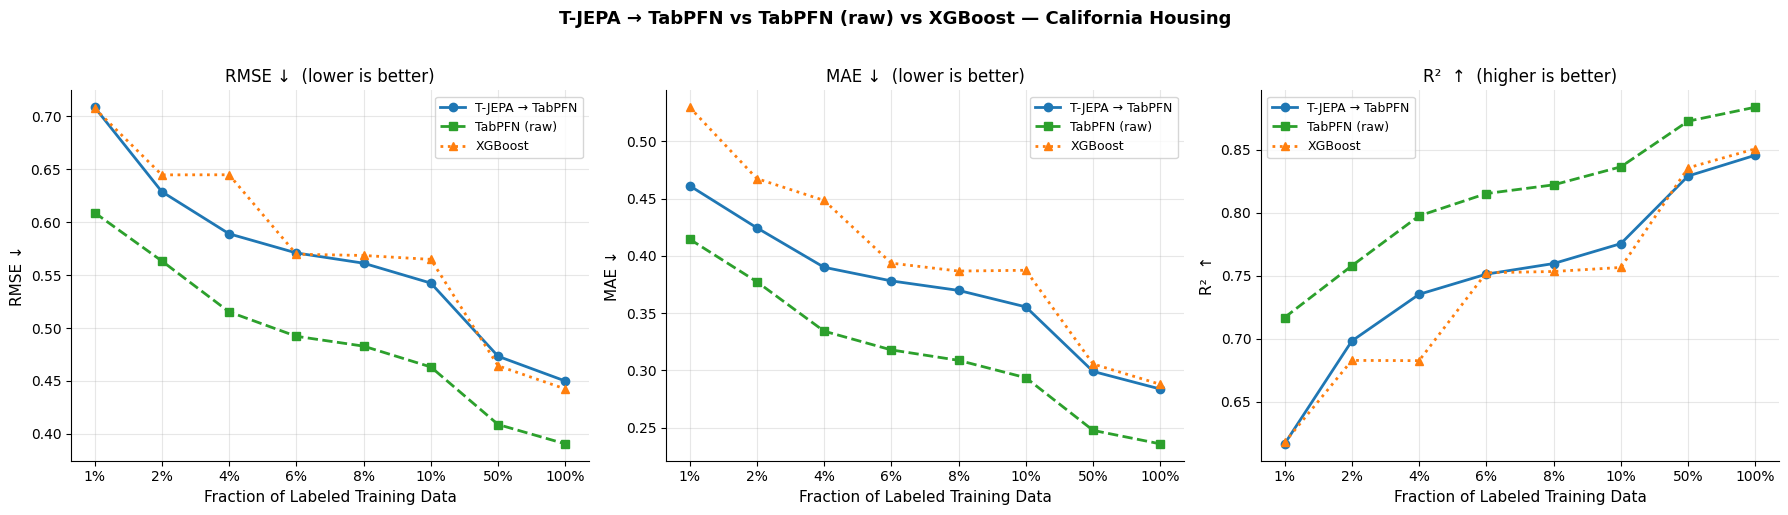

Plot saved.


In [10]:
# ── Cell 10: Visualization ─────────────────────────────────────────────────────
# 3-way comparison: T-JEPA→TabPFN vs raw TabPFN vs XGBoost
# Evenly spaced x-axis so small fractions don't crowd

tjepa_res = pd.read_csv('../results/tjepa_tabpfn_results.csv')
tjepa_res = tjepa_res[tjepa_res['dataset'] == 'california_housing'].sort_values('fraction').reset_index(drop=True)

tabpfn_res = pd.read_csv('../results/realtabpfn_results.csv')
tabpfn_res = tabpfn_res[tabpfn_res['dataset'] == 'california_housing'].sort_values('fraction').reset_index(drop=True)

xgb_res = pd.read_csv('../results/xgboost_results.csv')
xgb_res = xgb_res[xgb_res['dataset'] == 'california_housing'].sort_values('fraction').reset_index(drop=True)

x_pos    = np.arange(len(tjepa_res))
x_labels = [f"{int(f*100)}%" for f in tjepa_res['fraction'].values]

BLUE   = '#1f77b4'
GREEN  = '#2ca02c'
ORANGE = '#ff7f0e'

metrics = [
    ('rmse', 'RMSE ↓', 'lower is better'),
    ('mae',  'MAE ↓',  'lower is better'),
    ('r2',   'R²  ↑',  'higher is better'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('T-JEPA → TabPFN vs TabPFN (raw) vs XGBoost — California Housing',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (col, ylabel, note) in zip(axes, metrics):
    ax.plot(x_pos, tjepa_res[col].values,
            marker='o', linewidth=2, color=BLUE,   label='T-JEPA → TabPFN')
    ax.plot(x_pos, tabpfn_res[col].values,
            marker='s', linewidth=2, color=GREEN,  label='TabPFN (raw)',   linestyle='--')
    ax.plot(x_pos, xgb_res[col].values,
            marker='^', linewidth=2, color=ORANGE, label='XGBoost',        linestyle=':')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_xlabel('Fraction of Labeled Training Data', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{ylabel}  ({note})', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/tjepa_tabpfn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")